Dataset Understanding and Exploration

## 1. Dataset Understanding

The dataset consists of two main components: **transcripts** and **question–answer (QA) pairs**. These two parts are stored in separate folders and are linked through a common `video_id`.

### Dataset Structure

- **Transcript files** contain the spoken content of each video. Each transcript corresponds to a specific video and represents the textual version of the speech appearing in that video.
- **QA files** contain question–answer pairs derived from the corresponding transcripts. Each QA file is associated with a specific video and includes several questions related to segments of the transcript.

The QA files contain the following fields:

| Column | Description |
|------|-------------|
| `video_id` | Unique identifier of the video |
| `video_title` | Title of the video |
| `question_id` | Unique identifier of the question |
| `question` | The question related to a part of the transcript |
| `answer` | The answer extracted from the transcript |
| `difficulty` | Difficulty level of the question (e.g., Easy, Medium, Hard) |

An example QA entry is shown below:

| video_id | video_title | question | answer | difficulty |
|--------|-------------|---------|--------|-----------|
| 0urc3PabvOs | مصير الأرض و الشمس و كل شيء \| الدحيح | ماذا ورد في هذا الموضع من النص؟ | افتح موضوع جديد يا "ميدو"، أنا مش ناقص! | Easy |

### Dataset Size

The dataset contains:

- **13 transcript files**
- **3890 question–answer pairs**

Each transcript is associated with multiple QA pairs that refer to specific parts of the spoken content.

### Question and Answer Length Statistics

To better understand the linguistic characteristics of the dataset, we computed the average length of the questions and answers in terms of word count.

- **Average question length:** 6.08 words  
- **Average answer length:** 4.94 words  

These statistics indicate that both questions and answers are relatively short, which is expected for extractive question-answering tasks where answers are typically short phrases or sentences extracted from the transcript.

### Answer Length Distribution

The distribution of answer lengths was also examined to understand how verbose the answers tend to be. Most answers consist of short phrases, typically between **3 and 7 words**, reflecting the conversational nature of the transcripts and the extractive QA format used in the dataset.

Overall, this dataset represents a **spoken Arabic QA dataset**, where questions are linked to transcript segments of educational or informational videos. The dataset contains a mixture of **Modern Standard Arabic (MSA)** and **Egyptian dialect**, which makes it particularly suitable for studying language variation in spoken Arabic NLP tasks.

In [1]:
import sys
print(sys.executable)

c:\Users\DELL\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
transcript_folder = "../data/Transcripts"
qa_folder = "../data/QA"

In [4]:
transcripts = []

for file in os.listdir(transcript_folder):
    with open(os.path.join(transcript_folder, file), encoding="utf-8") as f:
        transcripts.append(f.read())

print("Number of transcripts:", len(transcripts))

Number of transcripts: 13


In [5]:
qa_data = []

for file in os.listdir(qa_folder):
    df = pd.read_csv(os.path.join(qa_folder, file))
    qa_data.append(df)

total_questions = sum(len(df) for df in qa_data)

print("Total QA pairs:", total_questions)

Total QA pairs: 3890


In [6]:
qa_data[0].head()

,video_id,video_title,question_id,question,answer,difficulty
0,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q001,ماذا ورد في هذا الموضع من النص؟,"افتح موضوع جديد يا ""ميدو""، أنا مش ناقص!",Easy
1,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q002,ما الجملة المذكورة في هذا السياق؟,وبعد كدا، هتنطفي هي كمان.,Medium
2,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q003,كيف صيغت العبارة هنا؟,- أيوة.,Easy
3,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q004,ما الذي قيل في هذا الجزء؟,- عشان كُل حاجة بتنتهي.,Medium
4,0urc3PabvOs,مصير الأرض و الشمس و كل شيء | الدحيح,0urc3PabvOs_Q005,ما النص الحرفي المذكور في هذه الفقرة؟,- عشان الفيزيا بتقول كدا.,Easy


In [7]:
# SAMPLE FROM TRANSCRIPT
print(transcripts[0][:1000])

0.0: سيادة الكولونيل، صبرك في محله،
3.076: مبروك علينا،
4.238: عملنا أفجر طيارة في تاريخ "أمريكا".
6.184: أنا متحمس جدًا من امبارح،
8.308: ها، ورّيني!
9.435: أقدم لحضرتك فخر الطيران الأمريكي
12.205: الـF-35.
15.218: بس دي شكلها شبه اللي احنا عملناها قبل كدا!
17.977: آه، بس التكنولوجيا اللي فيها
سابقة بسنين ضوئية، حضرتك.
22.165: يعني إيه سنين ضوئية؟!
23.379: مش مهم، مش مهم، احكيلي عنها كدا.
25.494: القطعة الفنية اللي أمام حضرتك دي
فيها أقوى كمبيوتر،
29.108: كمبيونر نسـ....
30.058: معلش، يعني، سؤال ساذج في حتة تانية،
32.133: بس هي بتقتلها تقريبًا كام طفل في الدقيقة؟
34.878: مش عارف، يا فندم، بصراحة...
ما على حسب فيه كام طفل واقفين،
38.444: يعني، ما اخترعنهاش عشان
تـTarget أطفال بالتحديد يعني...
41.523: طب معلش يعني، سؤال ساذج تاني يعني،
44.34: لو افترضنا إن هناك شخص،
45.835: ومثلًا مثلًا مثلًا، يعني، مثلًا،
47.616: مثلًا، مثلًا،
48.64: الشخص دا عربي،
50.225: ومعاه صاروخ مضاد للطيارات،
52.869: هل يقدر يوقّعها؟
54.319: حضرتك، هتفرق في إيه جنسيته؟!
56.004: انت هتخُشلي قافية ولّا إيه يا دكتو

## Dataset Structure ??? WILL EDIT

Exploratory Data Analysis (EDA)

In [8]:
# Question Length Distribution

all_questions = []

for df in qa_data:
    all_questions.extend(df["question"].tolist())

question_lengths = [len(q.split()) for q in all_questions]

print("Average question length:", sum(question_lengths)/len(question_lengths))

Average question length: 6.084832904884319


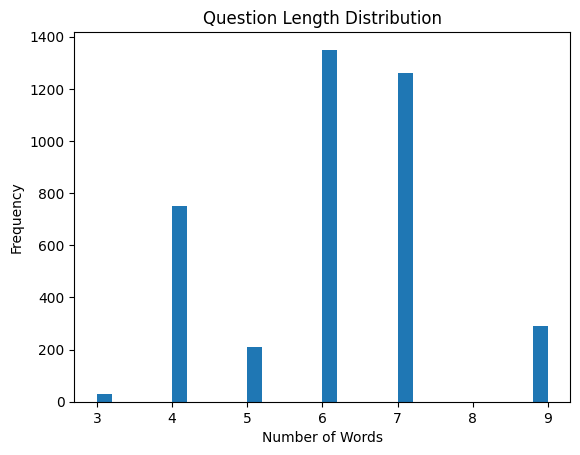

In [9]:
plt.hist(question_lengths, bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [10]:
from collections import Counter

question_counts = Counter(all_questions)

In [11]:
duplicate_questions = {q: c for q, c in question_counts.items() if c > 1}

print("Number of duplicated question types:", len(duplicate_questions))
total_duplicates = sum(c - 1 for c in question_counts.values() if c > 1)

print("Total duplicate questions:", total_duplicates)

Number of duplicated question types: 20
Total duplicate questions: 3580


In [12]:
top_duplicates = Counter(all_questions).most_common(20)

for q, count in top_duplicates:
    print(f"{q} → {count}")

ماذا ورد في هذا الموضع من النص؟ → 600
ما الجملة المذكورة في هذا السياق؟ → 600
كيف صيغت العبارة هنا؟ → 600
ما الذي قيل في هذا الجزء؟ → 600
ما النص الحرفي المذكور في هذه الفقرة؟ → 600
ماذا ورد في النص حول هذه الجزئية؟ → 60
ما الجملة المذكورة في هذا الموضع؟ → 60
كيف صيغت العبارة في النص؟ → 60
ما الذي قيل في هذا السياق؟ → 60
ما النص الحرفي المذكور هنا؟ → 60
في أي شهر وسنة تدور الأحداث؟ → 30
ما اسم الطائرة المذكورة؟ → 30
في أي ولاية جرت التجربة؟ → 30
ما اسم الشركة المصنعة؟ → 30
لماذا كان المقدم متحمسًا؟ → 30
ما سبب صعوبة إسقاط الطائرة؟ → 30
كم عدد اللغات في النظام؟ → 30
ما اسم المقدم؟ → 30
أين كان يقف المقدم؟ → 30
ماذا قيل عن التكنولوجيا؟ → 30


### Duplicate Question Analysis

We analyzed the distribution of questions across the dataset to identify repeated question patterns. Since the dataset uses template-based questions, several questions appear multiple times across different videos.

The duplicate analysis shows that a small set of question templates is reused throughout the dataset. This indicates that the task focuses on extracting the correct answer span from the transcript rather than interpreting diverse question formulations.

In [13]:
# Answer Length Distribution

all_answers = []

for df in qa_data:
    all_answers.extend(df["answer"].tolist())

answer_lengths = [len(a.split()) for a in all_answers]

print("Average answer length:", sum(answer_lengths)/len(answer_lengths))

Average answer length: 4.9406169665809765


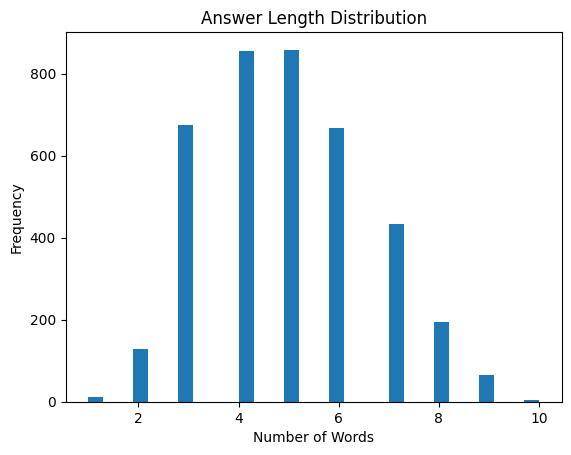

In [14]:
plt.hist(answer_lengths, bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [15]:
# Transcript Length Distribution
transcript_lengths = [len(t.split()) for t in transcripts]

print("Average transcript length:", sum(transcript_lengths)/len(transcript_lengths))

Average transcript length: 6875.2307692307695


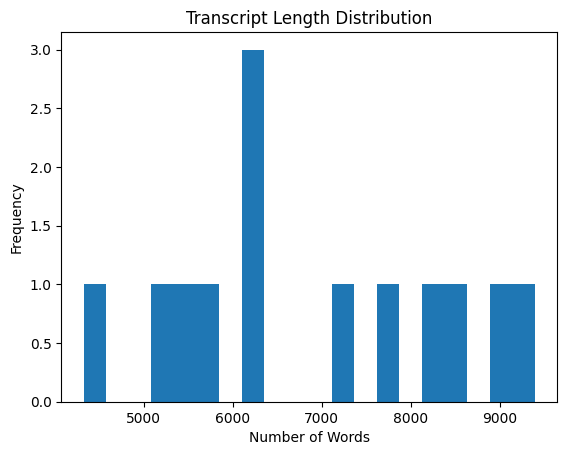

In [16]:
plt.hist(transcript_lengths, bins=20)
plt.title("Transcript Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [17]:
import arabic_reshaper
from bidi.algorithm import get_display

Transcript Word Frequency Detection

In [18]:
# Transcript Word Frequency Analysis
from collections import Counter

all_text = " ".join(transcripts)

tokens = all_text.split()

word_counts = Counter(tokens)

print(word_counts.most_common(20))

[('في', 1995), ('يا', 1806), ('عزيزي،', 1313), ('من', 1292), ('اللي', 1276), ('ما', 1135), ('إن', 916), ('على', 885), ('كان', 619), ('دا', 472), ('مش', 469), ('هو', 429), ('كل', 413), ('عشان', 365), ('زي', 341), ('دي', 338), ('انت', 296), ('بس', 263), ('كانت', 261), ('كدا،', 250)]


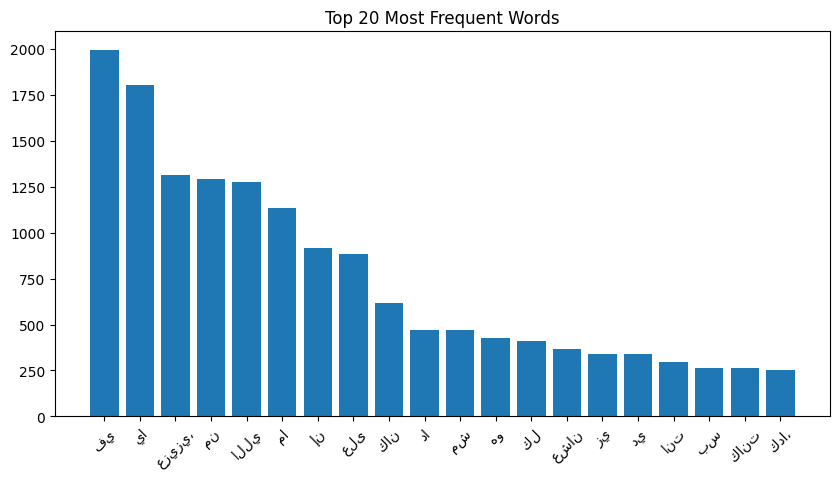

In [19]:
# Plotting Top Words
top_words = word_counts.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

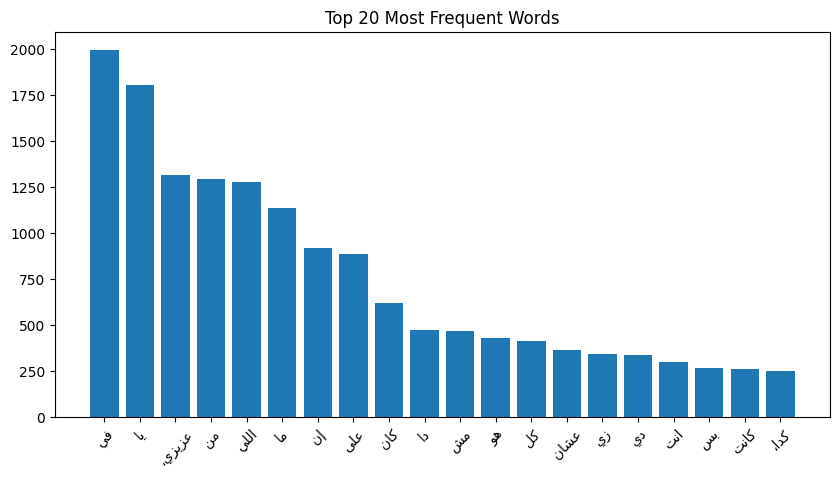

In [20]:
top_words = word_counts.most_common(20)

words = [get_display(arabic_reshaper.reshape(w[0])) for w in top_words]
counts = [w[1] for w in top_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words")
plt.xticks(rotation=45)
plt.show()

In [21]:
# Question Word Frequency Analysis

from collections import Counter

all_questions_text = " ".join(all_questions)

question_tokens = all_questions_text.split()

question_word_counts = Counter(question_tokens)

print(question_word_counts.most_common(20))

[('في', 3310), ('ما', 2390), ('هذا', 1920), ('النص', 1010), ('ورد', 950), ('الذي', 950), ('ماذا', 690), ('قيل', 690), ('النص؟', 660), ('الجملة', 660), ('المذكورة', 660), ('السياق؟', 660), ('كيف', 660), ('صيغت', 660), ('العبارة', 660), ('هنا؟', 660), ('الحرفي', 660), ('المذكور', 660), ('هذه', 660), ('الموضع', 600)]


In [22]:
# Answer Word Frequency Analysis

all_answers_text = " ".join(all_answers)

answer_tokens = all_answers_text.split()

answer_word_counts = Counter(answer_tokens)

print(answer_word_counts.most_common(20))

[('في', 718), ('اللي', 410), ('من', 393), ('ما', 261), ('على', 244), ('إن', 208), ('يا', 152), ('كان', 134), ('هو', 98), ('مش', 94), ('زي', 91), ('كل', 89), ('عشان', 88), ('فيها', 82), ('غير', 75), ('دا', 70), ('كانت', 67), ('عزيزي،', 67), ('هي', 66), ('احنا', 63)]


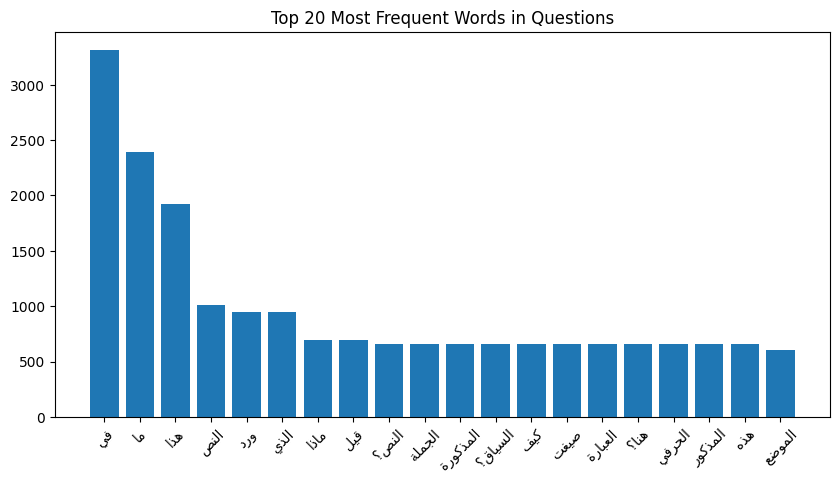

In [23]:
top_q_words = question_word_counts.most_common(20)

words = [get_display(arabic_reshaper.reshape(w[0])) for w in top_q_words]
counts = [w[1] for w in top_q_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words in Questions")
plt.xticks(rotation=45)
plt.show()

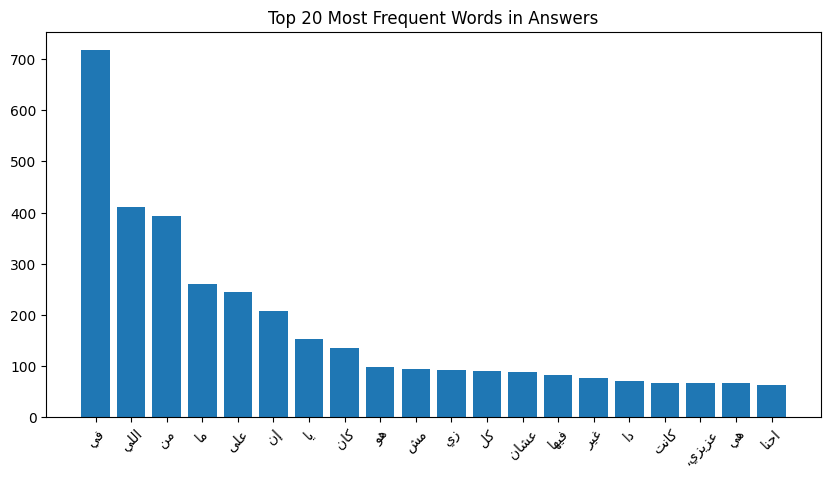

In [24]:
top_a_words = answer_word_counts.most_common(20)

words = [get_display(arabic_reshaper.reshape(w[0])) for w in top_a_words]
counts = [w[1] for w in top_a_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 20 Most Frequent Words in Answers")
plt.xticks(rotation=45)
plt.show()

Transcript TF-IDF Keyword Analysis

In [25]:
# TF-IDF Keyword Analysis
from sklearn.feature_extraction.text import TfidfVectorizer

# vectorizer = TfidfVectorizer()

from sklearn.feature_extraction.text import TfidfVectorizer

arabic_stopwords = [
"في","من","على","ما","يا","اللي","هو","هي","كان","كانت","دا","دي","مش"
]

vectorizer = TfidfVectorizer(stop_words=arabic_stopwords)

tfidf_matrix = vectorizer.fit_transform(transcripts)

feature_names = vectorizer.get_feature_names_out()

print("Number of documents:", tfidf_matrix.shape[0])
print("Vocabulary size:", tfidf_matrix.shape[1])

Number of documents: 13
Vocabulary size: 22176


In [26]:
import numpy as np

doc_index = 1

doc_vector = tfidf_matrix[doc_index].toarray()[0]

top_indices = np.argsort(doc_vector)[-10:]

print("This prints top TF-IDF words for transcript {0}. These should represent the topic of the episode.".format(doc_index))

for i in top_indices:
    print(feature_names[i])

This prints top TF-IDF words for transcript 1. These should represent the topic of the episode.
كائن
الدراع
زي
أخطبوط
الأنثى
كدا
دراع
إن
عزيزي
الأخطبوط


### Linguistic Patterns Observed in the Dataset

**Question Length Pattern**

The question length distribution shows that most questions are short, with an average length of approximately **6 words**. This suggests that the questions are designed to retrieve specific spans from the transcript rather than requiring complex reasoning or long contextual understanding.

**Answer Length Pattern**

The answers are even shorter, with an average length of around **5 words**. This confirms that the dataset follows an **extractive QA format**, where answers correspond to short spans directly taken from the transcript.

**Transcript Length Pattern**

Each transcript is relatively long, averaging around **6,875 words**. This indicates that the QA task requires identifying small answer spans within long narrative documents, which introduces a retrieval challenge for downstream models.

**Frequent Word Pattern**

Word frequency analysis reveals that the most common tokens include conversational and functional Arabic words such as:

- في  
- من  
- اللي  
- ما  
- يا  
- كان  

Many of these are **stopwords or discourse markers**, which reflects the **spoken and conversational nature** of the transcripts rather than formal written Arabic.

**Conversational Style Indicators**

The frequent appearance of words such as:

- يا  
- عشان  
- دا  
- مش  
- زي  

indicates the presence of **Egyptian dialect and informal conversational structures**, consistent with the narrative style of ElDa7ee7 episodes.

**Topic-Specific Vocabulary (TF-IDF)**

TF-IDF analysis highlights words that are particularly important within each transcript compared to the rest of the dataset. Unlike raw frequency counts, TF-IDF suppresses common words and emphasizes **topic-related vocabulary**, allowing us to identify key concepts discussed in each episode.

These keywords provide insight into the **main themes of each transcript** and help reveal the topical structure of the dataset.


Code-Switching Detection

In [27]:
import re
from collections import Counter

arabic_tokens = []
english_tokens = []
number_tokens = []

for t in transcripts:
    
    # Arabic words
    arabic = re.findall(r'[\u0600-\u06FF]+', t)
    
    # English words (≥3 letters)
    english = re.findall(r'\b[A-Za-z]{3,}\b', t)
    
    
    arabic_tokens.extend(arabic)
    english_tokens.extend(english)
  

# Counts
arabic_count = len(arabic_tokens)
english_count = len(english_tokens)


total_tokens = arabic_count + english_count 

print("Arabic tokens:", arabic_count)
print("English tokens:", english_count)


# Percentages
print("\nToken Distribution:")
print("Arabic tokens %:", round(arabic_count / total_tokens * 100, 2))
print("English tokens %:", round(english_count / total_tokens * 100, 2))


unique_english = set(english_tokens)
print("Unique English tokens:", len(unique_english))

english_counts = Counter(english_tokens)

print("Example English tokens detected:")
print(set(english_tokens))


print("Most common English words:")
print(english_counts.most_common(10))

Arabic tokens: 78996
English tokens: 675

Token Distribution:
Arabic tokens %: 99.15
English tokens %: 0.85
Unique English tokens: 473
Example English tokens detected:
{'Syndrome', 'remotely', 'Advantage', 'Rainbow', 'Fundamentally', 'discovered', 'Objective', 'Cross', 'Not', 'Americans', 'man', 'Satellites', 'Cofferdam', 'somewhere', 'Fiction', 'North', 'Laundry', 'Maverick', 'Simple', 'Shots', 'Fatherland', 'Maximum', 'Gun', 'Race', 'Artist', 'budget', 'ghetto', 'Law', 'Semelparous', 'Vikings', 'Zero', 'Eye', 'Noir', 'Embassy', 'focus', 'Planners', 'Bang', 'Grand', 'can', 'miracle', 'scan', 'time', 'campaign', 'Consortium', 'Shake', 'Founder', 'Polyamorous', 'Date', 'Fear', 'names', 'Loss', 'Pixel', 'Unlimited', 'reverse', 'the', 'Avatar', 'Empathy', 'Legula', 'their', 'Aspectus', 'Self', 'Recommendation', 'Interesting', 'Cult', 'Evolution', 'Agent', 'Protein', 'Planning', 'Universe', 'obsession', 'Base', 'Siphon', 'profile', 'Mughals', 'Wolfi', 'Data', 'Scripts', 'Progress', 'Mollus

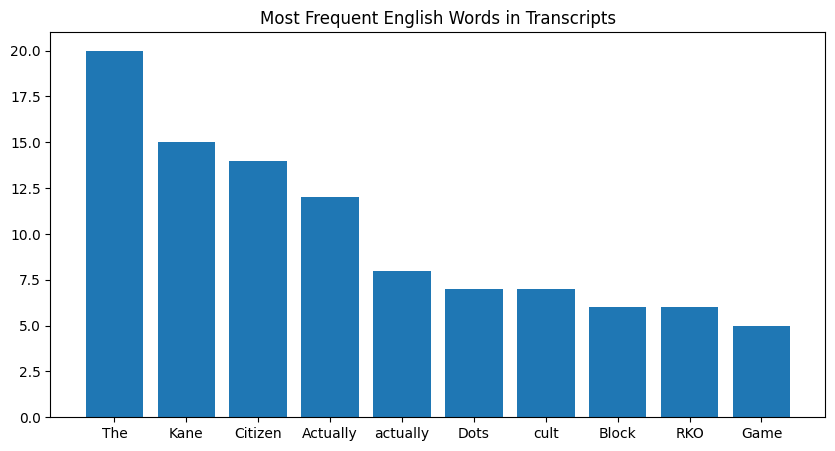

In [28]:
top_eng = english_counts.most_common(10)

words = [w[0] for w in top_eng]
counts = [w[1] for w in top_eng]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Most Frequent English Words in Transcripts")
plt.show()

Noise Detection and Normalization

In [29]:
import re

timestamps = []

for t in transcripts:
    found = re.findall(r"\d+\.\d+:", t)
    timestamps.extend(found)

print("Number of timestamps detected:", len(timestamps))
print("Example timestamps:", timestamps[:10])

Number of timestamps detected: 11109
Example timestamps: ['0.0:', '3.076:', '4.238:', '6.184:', '8.308:', '9.435:', '12.205:', '15.218:', '17.977:', '22.165:']


In [30]:
# Combine all transcripts into one string
all_text = " ".join(transcripts)

# Timestamps
timestamps = re.findall(r"\d+\.\d+:", all_text)
print("Number of timestamps detected:", len(timestamps))
print("Example timestamps:", timestamps[:10])


# Punctuation
punctuation = re.findall(r"[!?,.;:\"()\-\[\]؟!]", all_text)
print("Total punctuation symbols detected:", len(punctuation))
print("Example punctuation:", punctuation[:20])


# Diacritics 
diacritics = re.findall(r"[ًٌٍَُِّْ]", all_text)
print("Number of diacritics detected:", len(diacritics))
print("Example diacritics:", diacritics[:20])


alef_variants = re.findall(r"[إأآ]", all_text)
print("Number of Alef variants detected:", len(alef_variants))
print("Example Alef variants:", alef_variants[:20])

ya_variants = re.findall(r"ى", all_text)
print("Number of ى (Ya variants) detected:", len(ya_variants))
print("Example Ya variants:", ya_variants[:20])

ta_marbuta = re.findall(r"ة", all_text)
print("Number of Ta Marbuta detected:", len(ta_marbuta))
print("Example Ta Marbuta:", ta_marbuta[:20])


waw_hamza = re.findall(r"[ؤئ]", all_text)
print("Number of Waw/Hamza variants detected:", len(waw_hamza))
print("Example Waw/Hamza variants:", waw_hamza[:20])


tatweel = re.findall(r"ـ", all_text)
print("Number of Tatweel characters detected:", len(tatweel))
print("Example Tatweel:", tatweel[:10])


#  Special characters (anything non-text)
special_chars = re.findall(r"[^\u0600-\u06FFa-zA-Z0-9\s]", all_text)
print("Number of special characters detected:", len(special_chars))
print("Example special characters:", special_chars[:20])


Number of timestamps detected: 11109
Example timestamps: ['0.0:', '3.076:', '4.238:', '6.184:', '8.308:', '9.435:', '12.205:', '15.218:', '17.977:', '22.165:']
Total punctuation symbols detected: 33971
Example punctuation: ['.', ':', '.', ':', '.', ':', '"', '"', '.', '.', ':', '.', ':', '!', '.', ':', '.', ':', '-', '.']
Number of diacritics detected: 5568
Example diacritics: ['ً', 'ّ', 'ً', 'ً', 'ً', 'ً', 'ً', 'ً', 'ً', 'ّ', 'ُ', 'ّ', 'ُ', 'ً', 'ّ', 'ّ', 'َ', 'َ', 'ّ', 'ُ']
Number of Alef variants detected: 7900
Example Alef variants: ['أ', 'أ', 'أ', 'أ', 'أ', 'آ', 'إ', 'أ', 'أ', 'أ', 'إ', 'إ', 'إ', 'أ', 'إ', 'إ', 'إ', 'أ', 'أ', 'أ']
Number of ى (Ya variants) detected: 2185
Example Ya variants: ['ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى', 'ى']
Number of Ta Marbuta detected: 7701
Example Ta Marbuta: ['ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة', 'ة']
Number of Waw/Hamza variants detecte

In [31]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.normalization import normalize_arabic

clean_transcripts = [normalize_arabic(t) for t in transcripts]

# Example before/after
for i in range(3):
    print("Before:", transcripts[i][:100])
    print("After :", clean_transcripts[i][:100])
    print("-" * 50)

Before: 0.0: سيادة الكولونيل، صبرك في محله،
3.076: مبروك علينا،
4.238: عملنا أفجر طيارة في تاريخ "أمريكا".
6
After : سياده الكولونيل، صبرك في محله، مبروك علينا، عملنا افجر طياره في تاريخ امريكا انا متحمس جدا من امبارح
--------------------------------------------------
Before: 6.45: يا ربي!
7.756: أنا زهقت!
8.396: ما تثبت يا ابني بقى،
9.564: اثبت، تعبتني!
10.846: سيب الجهاز ي
After : يا ربي انا زهقت ما تثبت يا ابني بقي، اثبت، تعبتني سيب الجهاز يقرا بصراحه، انا مش عاجبني موضوع التجرب
--------------------------------------------------
Before: 0.167: منذ زمنٍ بعيد،
2.6: في أرضٍ ليست ببعيدة...
6.818: كان هُناك طفلٌ مصريٌ سمين،
10.204: يحلم بأن
After : منذ زمن بعيد، في ارض ليست ببعيده كان هناك طفل مصري سمين، يحلم بان يكون اول ساموراي مصري في العالم كب
--------------------------------------------------


In [32]:
import importlib
import src.normalization as normalization

importlib.reload(normalization)
remove_horof_el_jar = normalization.remove_horof_el_jar

clean_no_prepositions = [remove_horof_el_jar(t) for t in clean_transcripts]

# Show before/after
for i in range(3):
    print("Before:", clean_transcripts[i][:100])
    print("After :", clean_no_prepositions[i][:100])
    print("-" * 50)

Before: سياده الكولونيل، صبرك في محله، مبروك علينا، عملنا افجر طياره في تاريخ امريكا انا متحمس جدا من امبارح
After : سياده الكولونيل، صبرك محله، مبروك علينا، عملنا افجر طياره تاريخ امريكا انا متحمس جدا امبارح، ها، وري
--------------------------------------------------
Before: يا ربي انا زهقت ما تثبت يا ابني بقي، اثبت، تعبتني سيب الجهاز يقرا بصراحه، انا مش عاجبني موضوع التجرب
After : يا ربي انا زهقت ما تثبت يا ابني قي، اثبت، تعبتني سيب الجهاز يقرا صراحه، انا مش عاجبني موضوع التجربه 
--------------------------------------------------
Before: منذ زمن بعيد، في ارض ليست ببعيده كان هناك طفل مصري سمين، يحلم بان يكون اول ساموراي مصري في العالم كب
After : منذ زمن عيد، ارض يست بعيده ان هناك طفل مصري سمين، يحلم ان يكون اول ساموراي مصري العالم بر الطفل، وسا
--------------------------------------------------


In [33]:
import re
from collections import Counter

english_numbers = []
arabic_numbers = []

for t in clean_transcripts:
    
    # Western digits (0–9)
    eng_nums = re.findall(r'[0-9]+', t)
    
    # Arabic-Indic digits (٠١٢٣٤٥٦٧٨٩)
    ar_nums = re.findall(r'[٠-٩]+', t)
    
    english_numbers.extend(eng_nums)
    arabic_numbers.extend(ar_nums)

print("English numbers count:", len(english_numbers))
print("Arabic numbers count:", len(arabic_numbers))
print("Unique English numbers:", len(set(english_numbers)))
print("Unique Arabic numbers:", len(set(arabic_numbers)))

English numbers count: 830
Arabic numbers count: 0
Unique English numbers: 214
Unique Arabic numbers: 0


In [34]:
def detect_foreign_words(text):
    return re.findall(r'[A-Za-z]{3,}', text)

egyptian_dialect = ["زي","مش", "كده", "كدا", "إيه", "أيوة", "عايز", "هوه", "دي", "دا", "ليه", "ماشي"]

def detect_dialect_words(text):
    return [word for word in text.split() if word in egyptian_dialect]

foreign_tokens = [detect_foreign_words(t) for t in transcripts]
dialect_tokens = [detect_dialect_words(t) for t in transcripts]

all_foreign = [w for sublist in foreign_tokens for w in sublist]
all_dialect = [w for sublist in dialect_tokens for w in sublist]

print("Most common foreign words:", Counter(all_foreign).most_common(10))
print("Most common dialect words:", Counter(all_dialect).most_common(10))

print("Count of foreign words:", len(all_foreign))
print("Count of dialect words:", len(all_dialect))

Most common foreign words: [('The', 21), ('cult', 20), ('Kane', 15), ('Citizen', 14), ('Streltsy', 13), ('Actually', 12), ('Seppuku', 10), ('actually', 9), ('FBI', 9), ('Entropy', 8)]
Most common dialect words: [('دا', 472), ('مش', 469), ('زي', 341), ('دي', 338), ('كدا', 101), ('إيه', 99), ('عايز', 72), ('ليه', 49), ('كده', 36), ('ماشي', 25)]
Count of foreign words: 971
Count of dialect words: 2003


In [35]:
from collections import defaultdict

# Tokenize all text
tokens = all_text.split()

# Normalize words for detection only
def normalize_for_detection(word):
    word = re.sub(r"[ًٌٍَُِّْ]", "", word)      
    word = re.sub(r"[إأآ]", "ا", word)          
    word = re.sub(r"ى", "ي", word)               
    word = re.sub(r"ة", "ه", word)              
    word = re.sub(r"[ؤ]", "و", word)             
    word = re.sub(r"[ئ]", "ي", word)             
    word = re.sub(r"(.)\1{2,}", r"\1", word)     
    return word

groups = defaultdict(list)
for word in tokens:
    norm = normalize_for_detection(word)
    groups[norm].append(word)

# Show words with multiple forms
for norm_word, variations in groups.items():
    unique_variations = set(variations)
    if len(unique_variations) > 1:
        print(f"Normalized: {norm_word} -> Variations: {unique_variations}")

Normalized: انا -> Variations: {'أنا', 'انا', 'إنا'}
Normalized: جدا -> Variations: {'جدا', 'جدًا'}
Normalized: من -> Variations: {'مَن', 'من'}
Normalized: شبه -> Variations: {'شِبه', 'شبه', 'شَبَه'}
Normalized: اه، -> Variations: {'آه،', 'أه،'}
Normalized: ايه -> Variations: {'إيه', 'ايه'}
Normalized: كدا. -> Variations: {'كدا...', 'كدا.'}
Normalized: حته -> Variations: {'حتة', 'حته'}
Normalized: تقريبا -> Variations: {'تقريبا', 'تقريبًا'}
Normalized: طفل -> Variations: {'طفلٌ', 'طفل'}
Normalized: بصراحه. -> Variations: {'بصراحة...', 'بصراحة.'}
Normalized: علي -> Variations: {'علي', 'على', 'عِلي'}
Normalized: فيه -> Variations: {'فئة', 'فئه', 'فيه'}
Normalized: يعني. -> Variations: {'يعني...', 'يعني.'}
Normalized: طب -> Variations: {'طب', 'طِب'}
Normalized: ان -> Variations: {'إن', 'ان', 'أن'}
Normalized: هناك -> Variations: {'هناك', 'هُناك'}
Normalized: مثلا -> Variations: {'مثلًا', 'مثلا'}
Normalized: يقدر -> Variations: {'يُقدّر', 'يقدر'}
Normalized: انت -> Variations: {'أنت', 'انت

Cleaning is necessary because:
- Different spellings of the same word are treated as different tokens.
- Timestamps, punctuation, and special characters interfere with tokenization.
- Removing irrelevant prepositions simplifies the vocabulary.
- Dialectal and foreign words may not align with embeddings, reducing model performance.
- Normalization reduces vocabulary size, improves generalization.

In [36]:
all_words_before = len(set(all_text.split()))
all_words_after = len(set(" ".join(clean_no_prepositions).split()))
print("Unique words before cleaning:", all_words_before)
print("Unique words after cleaning :", all_words_after)

Unique words before cleaning: 36776
Unique words after cleaning : 20961


In [37]:
def remove_single_char_words(text):
    """
    Removes words that contain only one Arabic character.
    """
    words = text.split()
    
    filtered_words = [w for w in words if len(w) > 1]
    
    return " ".join(filtered_words)

## Dialect Analysis: MSA vs Egyptian Arabic

Since the dataset contains a mix of Modern Standard Arabic (MSA) and Egyptian dialect, we analyze the distribution of tokens belonging to each dialect.

To achieve this, we use the CAMeL Tools morphological analyzers for MSA (`calima-msa-r13`) and Egyptian Arabic (`calima-egy-r13`). Each token is analyzed and classified into one of the following categories:

- **MSA**: recognized only by the MSA analyzer  
- **EGY**: recognized only by the Egyptian analyzer  
- **BOTH**: recognized by both analyzers  
- **UNKNOWN**: not recognized by either analyzer

This analysis helps understand the linguistic composition of the dataset.

In [38]:
import re
from collections import Counter

from camel_tools.tokenizers.word import simple_word_tokenize
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer

In [39]:
all_text = " ".join(clean_no_prepositions)

In [40]:
tokens = simple_word_tokenize(all_text)

# keep only Arabic words
arabic_word_re = re.compile(r'^[\u0621-\u063A\u0641-\u064A]+$')
tokens = [t for t in tokens if arabic_word_re.match(t)]

print("Total tokens:", len(tokens))
print("Sample tokens:", tokens[:20])

Total tokens: 71927
Sample tokens: ['سياده', 'الكولونيل', 'صبرك', 'محله', 'مبروك', 'علينا', 'عملنا', 'افجر', 'طياره', 'تاريخ', 'امريكا', 'انا', 'متحمس', 'جدا', 'امبارح', 'ها', 'وريني', 'اقدم', 'حضرتك', 'فخر']


In [41]:
msa_db = MorphologyDB.builtin_db('calima-msa-r13')
egy_db = MorphologyDB.builtin_db('calima-egy-r13')

msa_analyzer = Analyzer(msa_db, backoff='NONE')
egy_analyzer = Analyzer(egy_db, backoff='NONE')

In [42]:
unique_words = list(set(tokens))

print("Unique words:", len(unique_words))

Unique words: 16805


In [43]:
def classify_word(word):
    msa_analyses = msa_analyzer.analyze(word)
    egy_analyses = egy_analyzer.analyze(word)

    in_msa = len(msa_analyses) > 0
    in_egy = len(egy_analyses) > 0

    if in_msa and not in_egy:
        return "MSA"
    elif in_egy and not in_msa:
        return "EGY"
    elif in_msa and in_egy:
        return "BOTH"
    else:
        return "UNKNOWN"

In [44]:
word_labels = {w: classify_word(w) for w in unique_words}
labels = [word_labels[w] for w in tokens]

In [45]:
counts = Counter(labels)

print("Dialect distribution:")
for k, v in counts.items():
    print(f"{k}: {v}")

word_df = pd.DataFrame({
    "word": tokens,
    "label": labels
})

Dialect distribution:
BOTH: 64288
EGY: 4784
UNKNOWN: 2855


In [46]:
summary = (
    word_df.groupby(["word", "label"])
    .size()
    .reset_index(name="count")
    .sort_values(["label", "count"], ascending=[True, False])
)

for label in ["MSA", "EGY", "BOTH", "UNKNOWN"]:
    print(f"\n--- {label} ---")
    print(summary[summary["label"] == label].head(10))


--- MSA ---
Empty DataFrame
Columns: [word, label, count]
Index: []

--- EGY ---
          word label  count
16707       يه   EGY    152
6884    دلوقتي   EGY     88
6898        ده   EGY     85
7698        سه   EGY     72
627       ازاي   EGY     64
6734     خليني   EGY     62
5851       تير   EGY     61
1763   التانيه   EGY     60
7241        ره   EGY     45
12248   هتلاقي   EGY     38

--- BOTH ---
        word label  count
15413     يا  BOTH   1853
4307      ان  BOTH   1801
8629   عزيزي  BOTH   1446
10134     ما  BOTH   1345
3462    اللي  BOTH   1278
6764      دا  BOTH   1176
4317     انت  BOTH    594
6926      دي  BOTH    506
10822     مش  BOTH    477
12451     هو  BOTH    440

--- UNKNOWN ---
            word    label  count
16705      ينيدي  UNKNOWN     96
2523   الساموراي  UNKNOWN     82
16708        يها  UNKNOWN     71
4743        تاعه  UNKNOWN     47
4535     اوزوالد  UNKNOWN     45
15282        ويس  UNKNOWN     36
7712        سوال  UNKNOWN     34
11523         نا  UNKNOWN    

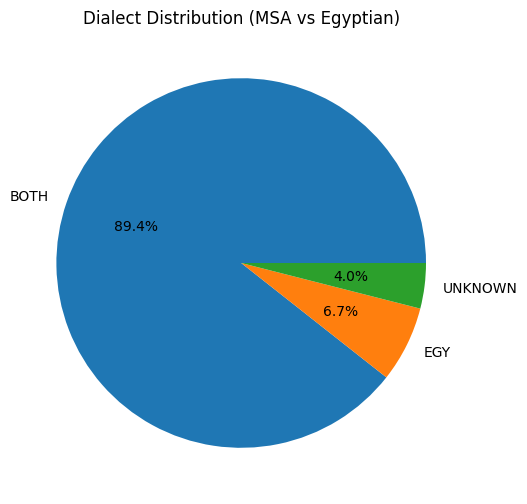

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%')
plt.title("Dialect Distribution (MSA vs Egyptian)")
plt.show()

## Tokenization & Text Representation

In this section, the cleaned Arabic transcripts, questions, and answers are converted into numerical form using the standard Keras `Tokenizer`.

The tokenizer is first fitted on the text data in order to build a word index (vocabulary). Then, each text is transformed into a sequence of integers, where each integer represents a token.

This step is necessary because machine learning and deep learning models cannot process raw text directly; they require numerical input instead.

The following tokenizer parameters are used:
- `num_words`: maximum number of words kept in the vocabulary
- `lower`: converts text to lowercase before tokenization
- `split`: defines how tokens are split
- `char_level`: specifies whether tokenization is at word level or character level
- `oov_token`: special token used for unknown words

In [48]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [49]:
clean_questions = [remove_horof_el_jar(normalize_arabic(str(q))) for q in all_questions]
clean_answers = [remove_horof_el_jar(normalize_arabic(str(a))) for a in all_answers]

clean_transcripts = [str(text) for text in clean_no_prepositions]


In [50]:
clean_transcripts = [remove_single_char_words(text) for text in clean_transcripts]
clean_questions = [remove_single_char_words(text) for text in clean_questions]
clean_answers = [remove_single_char_words(text) for text in clean_answers]

In [51]:
all_texts_for_tokenizer = clean_transcripts + clean_questions + clean_answers

print("Number of transcripts:", len(clean_transcripts))
print("Number of questions:", len(clean_questions))
print("Number of answers:", len(clean_answers))
print("Total texts used for tokenizer fitting:", len(all_texts_for_tokenizer))

Number of transcripts: 13
Number of questions: 3890
Number of answers: 3890
Total texts used for tokenizer fitting: 7793


In [52]:
# Initialize the tokenizer
tokenizer = Tokenizer(
    num_words=50000,
    lower=True,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
)

In [53]:
tokenizer.fit_on_texts(clean_transcripts)

In [54]:
word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))
print("First 20 items in word index:")

for i, (word, idx) in enumerate(word_index.items()):
    print(f"{word} -> {idx}")
    if i == 19:
        break

Vocabulary size: 20897
First 20 items in word index:
<OOV> -> 1
يا -> 2
ان -> 3
ما -> 4
عزيزي، -> 5
اللي -> 6
دا -> 7
انت -> 8
مش -> 9
دا، -> 10
هو -> 11
عشان -> 12
دي -> 13
زي -> 14
انا -> 15
انه -> 16
ابو -> 17
مع -> 18
فيه -> 19
حاجه -> 20


In [55]:
transcript_sequences = tokenizer.texts_to_sequences(clean_transcripts)
question_sequences = tokenizer.texts_to_sequences(clean_questions)
answer_sequences = tokenizer.texts_to_sequences(clean_answers)

In [56]:
print("Sample cleaned transcript:")
print(clean_transcripts[0])

print("\nTranscript as sequence:")
print(transcript_sequences[0])

print("\nSample cleaned question:")
print(clean_questions[0])

print("\nQuestion as sequence:")
print(question_sequences[0])

print("\nSample cleaned answer:")
print(clean_answers[0])

print("\nAnswer as sequence:")
print(answer_sequences[0])

Sample cleaned transcript:
سياده الكولونيل، صبرك محله، مبروك علينا، عملنا افجر طياره تاريخ امريكا انا متحمس جدا امبارح، ها، وريني اقدم حضرتك فخر الطيران الامريكي الF35 دي شكلها شبه اللي احنا عملناها قبل دا اه، التكنولوجيا اللي فيها سابقه سنين ضوييه، حضرتك يعني ايه سنين ضوييه؟ مش مهم، مش مهم، احكيلي عنها دا القطعه الفنيه اللي امام حضرتك دي فيها اقوي مبيوتر، مبيونر نس معلش، يعني، سوال ساذج حته تانيه، هي تقتلها تقريبا ام طفل الدقيقه؟ مش عارف، يا فندم، صراحه ما حسب فيه ام طفل واقفين، يعني، ما اخترعنهاش عشان تTarget اطفال التحديد يعني طب معلش يعني، سوال ساذج تاني يعني، افترضنا ان هناك شخص، ومثلا مثلا مثلا، يعني، مثلا، مثلا، مثلا، الشخص دا عربي، ومعاه صاروخ مضاد لطيارات، هل يقدر يوقعها؟ حضرتك، هتفرق ايه جنسيته؟ انت هتخشلي قافيه ولا ايه يا دكتور؟ رد السوال الطياره صعب جدا الرادار يلقطها، وصعب اي فرد يتتبعها ال سوال واحد صاحبي، اللي هو يفكر يشتري الModel دا يعني صاحبك؟ اتفضل هل النظام تاعها الانجليزي س؟ ولا ممكن يبقي اللهجه العبريه؟ ينفع، هي فيها غات ايه دا؟ ثانيه واحده ايه غات دي؟ اوعي يكون ف

In [57]:
transcript_lengths = [len(seq) for seq in transcript_sequences]
question_lengths = [len(seq) for seq in question_sequences]
answer_lengths = [len(seq) for seq in answer_sequences]

print("Average transcript length:", sum(transcript_lengths) / len(transcript_lengths))
print("Average question length:", sum(question_lengths) / len(question_lengths))
print("Average answer length:", sum(answer_lengths) / len(answer_lengths))

print("Max transcript length:", max(transcript_lengths))
print("Max question length:", max(question_lengths))
print("Max answer length:", max(answer_lengths))

Average transcript length: 5561.538461538462
Average question length: 5.06426735218509
Average answer length: 4.482005141388175
Max transcript length: 7597
Max question length: 7
Max answer length: 9


In [58]:
max_transcript_len = max(transcript_lengths)
max_question_len = max(question_lengths)
max_answer_len = max(answer_lengths)

padded_transcripts = pad_sequences(transcript_sequences, maxlen=max_transcript_len, padding='post', truncating='post')
padded_questions = pad_sequences(question_sequences, maxlen=max_question_len, padding='post', truncating='post')
padded_answers = pad_sequences(answer_sequences, maxlen=max_answer_len, padding='post', truncating='post')

In [59]:
print("Padded transcripts shape:", padded_transcripts.shape)
print("Padded questions shape:", padded_questions.shape)
print("Padded answers shape:", padded_answers.shape)

Padded transcripts shape: (13, 7597)
Padded questions shape: (3890, 7)
Padded answers shape: (3890, 9)


In [60]:
oov_index = tokenizer.word_index.get("<OOV>")

num_oov_in_transcripts = sum(token == oov_index for seq in transcript_sequences for token in seq)
num_oov_in_questions = sum(token == oov_index for seq in question_sequences for token in seq)
num_oov_in_answers = sum(token == oov_index for seq in answer_sequences for token in seq)

print("OOV index:", oov_index)
print("Number of OOV tokens in transcripts:", num_oov_in_transcripts)
print("Number of OOV tokens in questions:", num_oov_in_questions)
print("Number of OOV tokens in answers:", num_oov_in_answers)

OOV index: 1
Number of OOV tokens in transcripts: 0
Number of OOV tokens in questions: 8138
Number of OOV tokens in answers: 30


In [61]:
tokenization_summary = pd.DataFrame({
    "Metric": [
        "Vocabulary size",
        "Average transcript length",
        "Average question length",
        "Average answer length",
        "Max transcript length",
        "Max question length",
        "Max answer length",
        "OOV tokens in transcripts",
        "OOV tokens in questions",
        "OOV tokens in answers"
    ],
    "Value": [
        len(word_index),
        sum(transcript_lengths) / len(transcript_lengths),
        sum(question_lengths) / len(question_lengths),
        sum(answer_lengths) / len(answer_lengths),
        max(transcript_lengths),
        max(question_lengths),
        max(answer_lengths),
        num_oov_in_transcripts,
        num_oov_in_questions,
        num_oov_in_answers
    ]
})

tokenization_summary

,Metric,Value
0,Vocabulary size,20897.000000
1,Average transcript length,5561.538462
2,Average question length,5.064267
3,Average answer length,4.482005
4,Max transcript length,7597.000000
5,Max question length,7.000000
6,Max answer length,9.000000
7,OOV tokens in transcripts,0.000000
8,OOV tokens in questions,8138.000000
9,OOV tokens in answers,30.000000


### Limitations and Future Improvements

While the dataset is now prepared for modeling, several limitations remain:

- Many questions follow repetitive template structures, which may reduce linguistic diversity.
- The transcripts contain a mixture of Modern Standard Arabic and Egyptian dialect.
- Code-switching with English words and numbers is present in some segments.


Future milestones will explore improvements such as:

- improved context segmentation for transcript passages
- integration of pretrained Arabic language models